### 9. 텍스트를 위한 인공 신경망

#### 9-1. 순차 데이터와 순환 신경망

##### **순환 신경망 (Recurrent Neural Network, RNN)**

순차 데이터 처리에 특화된 신경망 구조로, 시간적 의존성을 모델링하는 핵심 기능인 순환(Recurrence)을 특징으로 함

- 구조적 특징: 일반적인 완전 연결 신경망과 유사하게 뉴런 간의 연결을 가지지만, 뉴런의 출력이 다시 자기 자신에게 입력으로 전달되는 순환 연결이 추가

- 데이터 재사용: 특정 샘플(시퀀스의 아이템)을 처리할 때, 바로 이전 타임스텝에서 사용했던 데이터(은닉 상태)를 재사용합니다. 즉, 모델 내부에서 기억 장치 역할을 수행

- 핵심 용어
  - 타임스텝 (Timestep): 시퀀스를 처리하는 한 단계를 의미 (예: 문장에서 단어 하나 처리)
  - 셀 (Cell): 순환층을 표현하는 단위. 실제로는 여러 뉴런을 포함하지만, 복잡한 순환 연결을 간결하게 표현하기 위해 하나의 셀로 시각화
  - 은닉 상태 (Hidden State, $h_t$): 셀의 출력이자, 이전 타임스텝의 정보가 압축되어 다음 타임스텝으로 전달되는 재사용 데이터

-  작동 원리: 셀은 현재 타임스텝의 입력과 이전 타임스텝의 은닉 상태($h_{t-1}$)를 결합하여 현재 타임스텝의 은닉 상태($h_t$)를 생성합니다. 이때 이전 은닉 상태에 곱해지는 별도의 순환 가중치가 존재합니다.

---


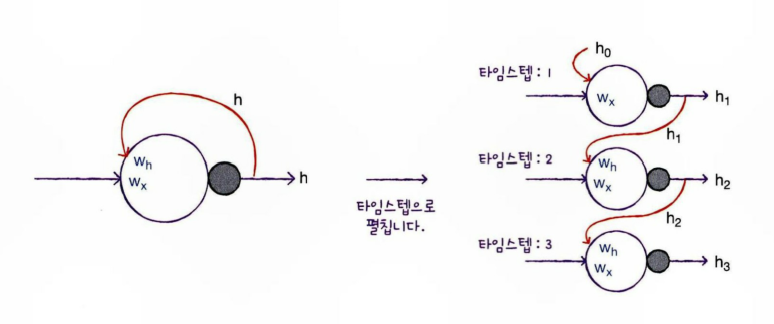

**순차 데이터**

- 순서에 의미가 있어 시간적/논리적 흐름이 중요한 데이터를 통칭

- 특징: 데이터 포인트 간의 순서가 전체 정보를 구성하는 데 필수적입니다.

- 예시: 텍스트 데이터(문장, 단어의 나열), 시계열 데이터(주가, 센서 값), 음성 데이터 등

  RNN은 이러한 순차 데이터의 시간적 종속성을 효과적으로 포착하기 위해 설계

---

**피드포워드 신경망 (Feedforward Neural Network, FFNN)**

- 데이터의 흐름이 앞(입력)으로만 진행되는 비순환적인 신경망 구조

- 구조적 특징: 입력층에서 출력층으로 데이터가 한 방향으로만 전달되며, 순환적인 Feedback 연결이 없음

- 대표 모델: **완전 연결 신경망(Fully Connected Network)** 과 합성곱 신경망(Convolutional Neural Network, CNN) 등

- 뉴런 연산: 뉴런은 입력 데이터에 가중치를 곱하고(Weight multiplication) 절편을 더한 후, 이를 활성화 함수에 통과시켜 출력을 생성

- 활성화 함수: 은닉층에 흔히 사용되는 활성화 함수 중 하나로 **하이퍼볼릭 탄젠트 함수($\tanh$)** 사용. $\tanh$는 입력값을 $(-1, 1)$ 범위로 출력하여 그라디언트 소실 문제를 완화하는 데 도움을 줌

---


##### **셀의 가중치와 입출력**


**1) 모델 파라미터 (가중치 및 절편) 계산**

RNN 셀 내의 학습 가능한 파라미터는 크게 세 부분으로 구성되며, 이는 모델의 복잡도를 포현

(입력 특성 $I=4$, 뉴런 수 $H=3$ 가정)

- 입력 가중치 ($w_x$): 현재 타임스텝의 입력과 순환층 뉴런 사이의 연결

  $  w_x = I \times H = 4 \times 3 = 12$

- 순환 가중치 ($w_h$):

  이전 타임스텝의 은닉 상태($h_{t-1}$)와 현재 타임스텝 뉴런 사이의 연결

  은닉 상태가 모든 뉴런에 완전히 연결되므로, 이는 뉴런 간의 완전 연결과 같음

  $  w_h = H \times H = 3 \times 3 = 9$

- 절편 (Bias): 각 뉴런마다 하나의 절편이 필요

  $  \text{절편} = H = 3$


**2) 순환층의 입출력 구조**

RNN은 시퀀스 데이터를 처리하며, 입력과 출력의 차원이 시퀀스의 특징에 따라 변화

- **입력 데이터 형태**

  순환층의 샘플 입력은 일반적으로 2차원 배열

    - 차원 1: 시퀀스 길이 (타임스텝):
  
      문장의 단어 수, 시계열 데이터의 시간 길이 등
  
      (예: "I am a boy" $\to$ 4개 단어)
  
    - 차원 2: 특성/단어 표현 차원:
  
      각 타임스텝(단어)을 표현하는 벡터의 크기 (예: 100차원)
  
      입력 차원 예: (타임스텝, 특성 차원) $\to$ (20, 100)
    
- **출력 데이터 형태 (Keras 기본 설정)**
  
  순환층은 입력된 모든 시퀀스 정보를 통합하여 출력
  
  - 기본 동작: 마지막 타임스텝의 은닉 상태($h_f$)만 출력으로 내보냄
  
  - 이는 시퀀스 전체 정보를 압축하여 최종 상태에 저장하는 것으로 해석
  
  - 출력 차원: 1차원 배열로, 크기는 순환층의 뉴런 개수와 같음
    
    (20, 100) 입력, 뉴런 10개 $\to$ (10,) 출력

**3) 다층 순환 신경망 구성**

여러 개의 순환층을 쌓아 깊은(Deep) RNN을 구성 가능

- 중간 순환층: 다음 층이 시퀀스 전체 정보를 처리할 수 있도록, 모든 타임스텝의 은닉 상태를 출력해야 함

- 최종 순환층: 시퀀스 처리를 마무리하고 분류층으로 전달하기 위해, 마지막 타임스텝의 은닉 상태만 출력

**4) 출력층**

RNN 셀의 최종 출력이 1차원이기 때문에, 합성곱 신경망(CNN)에서 필요했던 Flatten 클래스 없이 바로 밀집층(Dense Layer)에 연결 가능

- 다중 분류: 출력층 뉴런 수 = 클래스 개수, 활성화 함수 = 소프트맥스(softmax)

- 이진 분류: 출력층 뉴런 수 = 1개, 활성화 함수 = 시그모이드(sigmoid)

---

#### 9-2. 순환 신경망으로 IMDB 리뷰 분류하기

##### **IMDB 리뷰 데이터셋**

인터넷 영화 데이터베이스인 imdb.com에서 수집한 리뷰를 감상평에 따라 긍정과 부정으로 분류해 놓은 데이터셋

총 50,000개의 샘플로 이루어져 있고 훈련 데이터와 테스트 데이터에 각각 25,000개씩 나누어져 있음



**자연어 처리 (Natural Language Processing, NLP)**

컴퓨터(기계)를 사용하여 인간의 언어(자연어)를 이해하고 처리하는 인공지능 분야

- 주요 세부 분야
    - 음성 인식: 사람의 음성(소리) 데이터를 텍스트로 변환하는 기술
    
    - 기계 번역: 한 언어를 다른 언어로 자동으로 번역하는 기술
    
    - 감성 분석: 텍스트에 담긴 주관적인 의견, 태도, 감정 등을 긍정/부정 등으로 분류하거나 정량화하는 작업
      
      예시: IMDB 영화 리뷰를 읽고 감상평(긍정/부정)에 따라 분류하는 작업

- 핵심 용어

    - 말뭉치 (Corpus): NLP 분야에서 모델 훈련에 사용되는 훈련 데이터셋을 부르는 용어

      예시: IMDB 리뷰 데이터셋 전체가 하나의 말뭉치로 간주될 수 있음

**토큰 (Token)**

문장을 공백이나 구둣점 기준으로 분리했을 때 얻는 의미 있는 최소 단위 (주로 단어)

**단어-정수 매핑**

텍스트 데이터를 컴퓨터가 처리할 수 있도록 단어마다 고유한 정수를 부여하는 수치화 과정. (정수의 크기는 단어의 의미와 무관함)

**어휘 사전**

훈련 세트에서 추출한 고유한 단어(토큰)들의 목록

텍스트 데이터를 신경망에 입력할 수 있는 정수 인덱스로 변환하는 데 사용되는 기준표

**예약된 정수**
어휘 사전 내의 일반적인 단어 외에, 특정 용도를 위해 미리 할당해 놓은 정수 인덱스

|정수|용도|설명|
|:---:|---|---|
|0|패딩 (Padding)|시퀀스의 길이를 맞추기 위해 사용되는 정수 값|
|1|문장 시작|입력 시퀀스의 시작을 나타내는 토큰|
|2|어휘 사전에 없는 토큰|테스트 세트 등에서 발견되었으나 어휘 사전에 포함되지 않은 단어를 대체하는 토큰|

In [1]:
from keras.datasets import imdb

2025-12-09 23:14:50.365805: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-09 23:14:50.394434: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765289690.420347   43333 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765289690.428380   43333 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-09 23:14:50.464424: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# 전체 데이터셋에서 가장 자주 등장하는 단어 200개만 추출
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=200)

`imdb.load_data()`함수는 전체 어휘 사전에 있는 단어를 등장 횟수대로 나열한 다음 가장 많이 등장한 200개의 단어 선택

In [3]:
# 훈련 세트와 테스트 세트의 크기 확인
print(train_input.shape, test_input.shape)

(25000,) (25000,)


IMDB 리뷰 텍스트는 길이가 제각각이기 때문에 고정 크기의 2차원 배열에 담기 보다는 

리뷰마다 별도의 파이썬 리스트로 담아야 메모리를 효율적으로 사용할 수 있음

In [4]:
# 첫 번째 리뷰 길이 확인
print(len(train_input[0]))

218


In [5]:
# 두 번째 리뷰 길이 확인
print(len(train_input[1]))

189


In [6]:
# 첫 번째 리뷰에 담긴 내용 출력
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


실제 IMDB 리뷰 데이터셋은 영어로 된 문장이지만 편리하게도 케라스에는 이미 정수로 바꾼 데이터가 포함되어 있음을 확인 가능

In [7]:
# 타깃 데이터 출력
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [8]:
# 훈련 세트와 검증 세트 구분
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

In [9]:
# 각 리뷰의 길이를 계산해 넘파이 배열에 담아 평균적인 리뷰의 길이와 가장 짧은 리뷰의 길이 그리고 가장 긴 리뷰의 길이를 확인
# 넘파이 리스트 내포를 사용해 train_input의 원소를 순회하면서 길이 측정
import numpy as np

lengths = np.array([len(x) for x in train_input])

In [10]:
# 리뷰 길이의 평균과 중간값 확인
print(np.mean(lengths), np.median(lengths))

239.00925 178.0


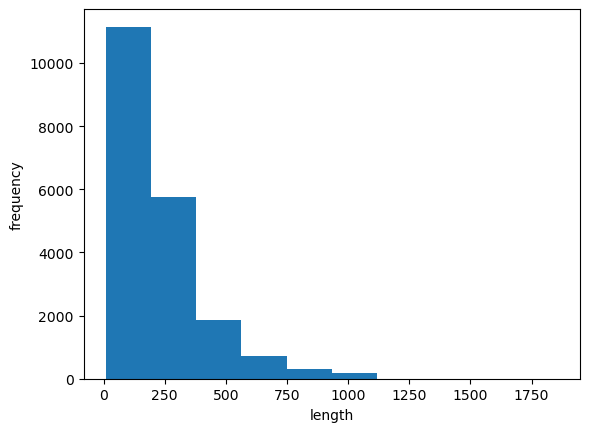

In [11]:
# lengths 배열 히스토그램 확인
import matplotlib.pyplot as plt

plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

중간값보다 훨씬 짧은 리뷰들의 길이를 100에 맞추기 위해 패딩 필요

In [12]:
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)

`maxlen`에 원하는 길이를 지정하면 이보다 긴 경우는 잘라내고 짧은 경우는 0으로 패딩

In [13]:
print(train_seq.shape)

(20000, 100)


In [14]:
# 첫 번째 샘플 출력
print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


In [15]:
# 원본 샘플의 끝 확인
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


마지막 10개의 토큰이 일치하므로 샘플이 앞부분이 잘렸다는 것을 짐작할 수 있음

pad_sequences() 함수는 기본으로 maxlen보다 긴 시퀀스의 앞부분을 자름

이렇게 하는 이유는 일반적으로 시퀀스의 뒷부분의 정보가 더 유용하리라 기대하기 때문

In [16]:
# 여섯 번째 샘플 출력
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


앞 부분에 0이 있는 것으로 보아 이 샘플의 길이는 100이 안되는 것을 확인

패딩 토큰은 시퀀스의 뒷부분이 아니라 앞부분에 추가

시퀀스의 마지막에 있는 단어가 셀의 은닉 상태에 가장 큰 영향을 미치게 되므로 마지막에 패딩을 추가하는 것은 일반적으로 선호
하지 않음

In [17]:
# 검증 세트의 길이도 100으로 조정
val_seq = pad_sequences(val_input, maxlen=100)

---

#####  순환 신경망 만들기

IMDB 리뷰 분류 문제는 이진 분류이므로 마지막 출력층은 1개의 뉴런을 가지며 시그모이드 활성화 함수를 사용해야 함

In [18]:
import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,200)))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

W0000 00:00:1765289700.920830   43333 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


- Dense나 Conv2D 클래스 대신 SimpleRNN 클래스 사용

- Input 함수의 입력 차원을 (100, 200)으로 지정

    - 100: 샘플의 길이 
    
    - 200: 토큰을 표현하는 벡터의 크기를 의미하며, 원-핫 인코딩의 크기에서 비롯된 숫자

- SimpleRNN 클래스에 사용할 뉴런 개수 지정
    
    activation 매개변수의 기본 값은 'tanh'으로 그대로 사용


**원-핫 인코딩**

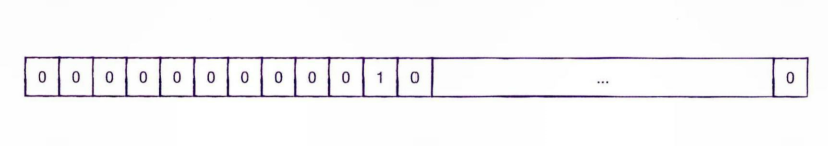

- 어휘 사전 크기 및 정수 범위 결정

    - 어휘 제한: imdb.load_data() 함수를 사용하여 200개의 단어만 사용하도록 제한고
    
    - 고유 단어 개수: 이 제한으로 인해 훈련 데이터에 사용되는 고유한 단어는 총 200개로 한정됨
    
    - 정수 범위: 이 200개의 단어는 인덱스 0부터 199까지의 정숫값으로 매핑
    
        (0은 패딩 등 예약 토큰일 수 있으나, 여기서는 총 개수 200개에 포함됨)
        
- 원-핫 인코딩 차원 결정
    
    - 필요성: 토큰의 정숫값 사이에 있는 크기 속성을 제거하고 각 토큰을 고유하게 표현하기 위해 원-핫 인코딩이 필요
    
    - 차원 크기: **고유한 단어 개수(200개)** 가 곧 원-핫 인코딩 배열의 길이가 됨
    
    - 결과: 각 토큰은 길이 200의 배열로 표현되며, 단 하나의 인덱스만 1이고 나머지는 모두 0이 됨
    
    - 개념적 비유: 이 과정은 이전에 예시로 들었던 "단어 하나를 3개의 숫자($\to$ 200개의 숫자)로 표현"하는 것과 개념적으로 동일

In [19]:
# 정수 배열을 자동으로 원-핫 인코딩된 배열로 반환
train_oh = keras.utils.to_categorical(train_seq)

In [20]:
# 배열 크기 출력
print(train_oh.shape)

(20000, 100, 200)


정수 하나마다 모두 200차원의 배열로 변경되었기 때문에 (20000, 100) 크기의 train_seq가 (20000, 100, 200) 크기의 train_oh로 변경

이렇게 샘플 데이터의 크기가 1차원 정수 배열 (100, )에서 2차원 배열 (100, 200)로 바꾸었으므로 

Input 함수의 shape 매개변수의 값을 (100, 200)으로 지정해야 함

In [21]:
# train_oh의 첫 번째 샘플의 첫 번째 토큰 10의 인코딩 결과 확인
print(train_oh[0][0][:12])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [22]:
# 넘파이 함수를 이용해 나머지 원소가 모두 0인지 확인
print(np.sum(train_oh[0][0]))

1.0


In [23]:
# val_seq도 원-핫 인코딩으로 변환
val_oh = keras.utils.to_categorical(val_seq)

In [24]:
# 모델 구조 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

이 순환층은 마지막 타임스텝의 은닉 상태만 출력하기 때문에 출력 크기가 순환층의 뉴런 개수와 동일한 8임을 확인할 수 있음

---

##### **순환 신경망 훈련하기**

In [25]:
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras', 
                                                save_best_only=True)
ealry_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64,
                    validation_data=(val_oh, val_target),
                    callbacks=[checkpoint_cb, ealry_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5019 - loss: 0.6956 - val_accuracy: 0.5418 - val_loss: 0.6898
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5471 - loss: 0.6870 - val_accuracy: 0.5482 - val_loss: 0.6817
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6240 - loss: 0.6516 - val_accuracy: 0.6322 - val_loss: 0.6447
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6700 - loss: 0.6188 - val_accuracy: 0.6988 - val_loss: 0.5940
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6972 - loss: 0.5895 - val_accuracy: 0.6986 - val_loss: 0.5884
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7004 - loss: 0.5836 - val_accuracy: 0.7116 - val_loss: 0.5715
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7119 - loss: 0.5728 - val_accuracy: 0.7068 - val_loss: 0.5751
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7184 - loss: 0.5616 - 

15번째 에포크에서 조기 종료

검증 세트에 대한 정확도는 약 72%

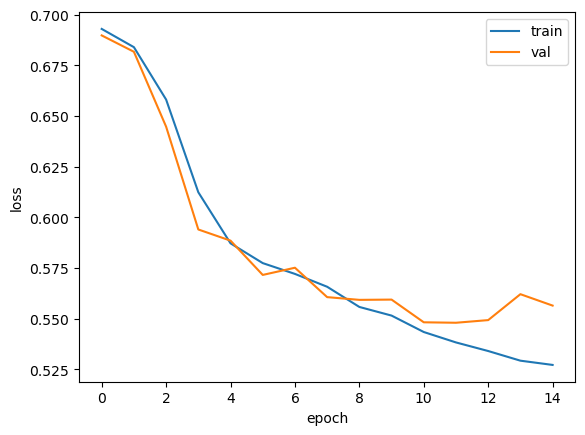

In [26]:
# 훈련 손실과 검증 손실을 그래프로 확인
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

원-핫 인코딩의 단점: 데이터가 엄청 커짐 

In [27]:
# train_seq 배열과 train_oh 배열의 nbytes 속성을 출력하여 크기 확인
print(train_seq.nbytes, train_oh.nbytes)

8000000 3200000000


---

##### **단어 임베딩 사용하기**

**단어 임베딩**

순환 신경망에서 텍스트 데이터를 효율적이고 의미 있게 처리하기 위해 주로 활용

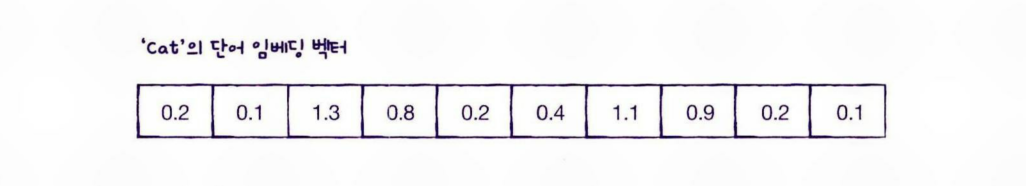

- 핵심 처리 방식

    텍스트의 각 단어를 고정된 크기의 실수 벡터로 변환하는 방법

    변환 목표: 토큰(단어) 자체의 정수 인덱스가 아닌, 그 단어가 가진 의미와 문맥적 관계를 내포하는 밀집(Dense) 벡터를 생성

- 성능상의 이점

    - 단어 임베딩은 기존의 원-핫 인코딩 대비 자연어 처리(NLP) 작업에서 더 좋은 성능을 제공

    - 의미 있는 값: 임베딩 벡터는 단순한 0과 1로 채워진 원-핫 인코딩과 달리, 단어의 의미적 유사성을 반영하는 실수 값으로 채워져 있음
    
    - 관계 학습: 이를 통해 신경망은 단어 간의 복잡한 문맥적, 의미적 관계를 학습하고 활용할 수 있게 됨

- 효율성 측면의 장점

    단어 임베딩은 메모리 및 연산 효율성 측면에서도 큰 이점을 가짐

    - 효율적인 메모리 사용: 신경망의 입력으로 정수 데이터(단어 인덱스)를 받기 때문에, 모든 단어를 원-핫 인코딩 벡터로 변환하는 경우(대규모 희소 벡터)보다 메모리를 훨씬 효율적으로 사용할 수 있응

    - 파라미터 학습: 정수 입력을 받은 후, 모델 내부의 임베딩 층에서 이 정수를 저차원의 실수 벡터로 변환하는 파라미터(가중치)를 학습

In [28]:
# 많이 등장하는 500개 단어까지 선택해서 단어 임베딩된 데이터셋 준비 
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [29]:
# Embedding 클래스를 추가한 두 번째 순환 신경망 생성
model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))
model_emb.add(keras.layers.Embedding(500, 16))      # 16은 임베딩 벡터의 크기 
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))

In [30]:
# 모델 구조 출력
model_emb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# 모델 훈련
model_emb.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras', 
                                                save_best_only=True)
ealry_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, ealry_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5266 - loss: 0.6909 - val_accuracy: 0.5924 - val_loss: 0.6680
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6258 - loss: 0.6482 - val_accuracy: 0.6290 - val_loss: 0.6351
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7004 - loss: 0.5811 - val_accuracy: 0.7378 - val_loss: 0.5462
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7577 - loss: 0.5125 - val_accuracy: 0.7174 - val_loss: 0.5861
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7641 - loss: 0.5057 - val_accuracy: 0.7566 - val_loss: 0.5234
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7846 - loss: 0.4722 - val_accuracy: 0.7644 - val_loss: 0.5022
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7989 - loss: 0.4509 - val_accuracy: 0.7674 - val_loss: 0.4963
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8103 - loss: 0.4307 -

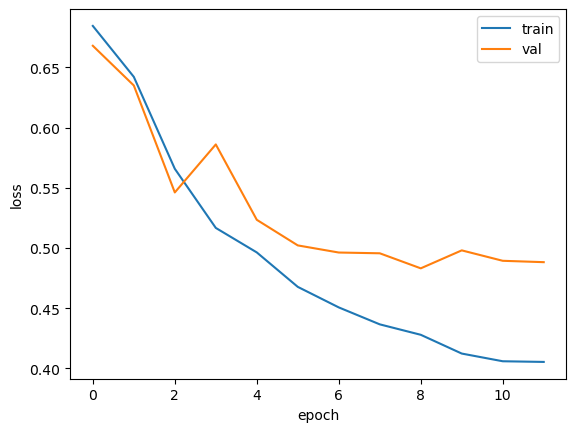

In [32]:
# 훈련 손실과 검증 손실을 그래프로 확인
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

---

#### 9-3. LSTM과 GRU셀

##### **LSTM 구조**

기본 순환 신경망(RNN)이 긴 시퀀스 데이터를 처리할 때 기억을 잃어버리는 문제를 해결하기 위해, 단기 기억을 오랫동안 유지할 수 있도록 고안

1\) 상태
- 셀 상태 (Cell State, $c$)
    - 역할: LSTM의 장기 기억을 담당하는 핵심 요소
    - 특징
        다음 층으로 전달되지 않고, 현재 셀 내부에서만 순환하며 정보가 유지됨<br>
        정보가 거의 변하지 않고 흐르도록 설계되어(컨베이어 벨트처럼), 긴 시퀀스에서도 데이터가 잘 보존됨

- 은닉 상태 (Hidden State, $h$)
    - 역할: 단기 기억을 담당하며, 실제 다음 타임스텝의 입력과 다음 층으로 전달되는 출력값
    - 생성: 갱신된 셀 상태를 기반으로 계산

2\) 게이트

LSTM 셀은 '작은 셀' 역할을 하는 3개의 게이트를 통해 정보의 흐름(삭제, 저장, 출력)을 정교하게 제어하며, 각 게이트는 서로 다른 가중치($W_f, W_o$ 등)를 가지며 독립적으로 훈련
- 삭제 게이트 
    - 기능: 이전 기억(셀 상태) 중 불필요한 정보를 삭제하는 역할
    - 작동: 
        - 입력($x$)과 이전 은닉 상태($h_{t-1}$)를 가중치($W_f$)와 곱한 후 시그모이드($\sigma$) 함수를 통과시킴
        - 결과가 0에 가까우면 정보 삭제, 1에 가까우면 정보 유지
        - 이 값을 이전 셀 상태와 곱함
- 입력 게이트 
    - 기능: 현재의 새로운 정보를 셀 상태에 추가(저장)하는 역할
    - 작동: 두 가지 단계가 결합되어 셀 상태에 더해짐
        - 정보 필터링: 시그모이드 함수를 통해 어떤 정보를 저장할지 결정
        - 새 정보 생성: tanh 함수를 통해 새로운 후보 값(정보)을 생성
        - 결합: 위 두 결과를 곱하여 셀 상태에 더해줌
- 출력 게이트
    - 기능: 다음 타임스텝으로 전달할 은닉 상태($h_t$)를 결정하는 역할
    - 작동
        - 입력과 이전 은닉 상태를 사용하여 시그모이드 함수를 통과시킴
    (출력할 양 결정)
        - 현재의 셀 상태($c_t$)를 tanh 함수에 통과시킴 (값의 범위를 -1~1로 조정)
        - 두 값을 곱하여 최종 은닉 상태를 만듭니다.

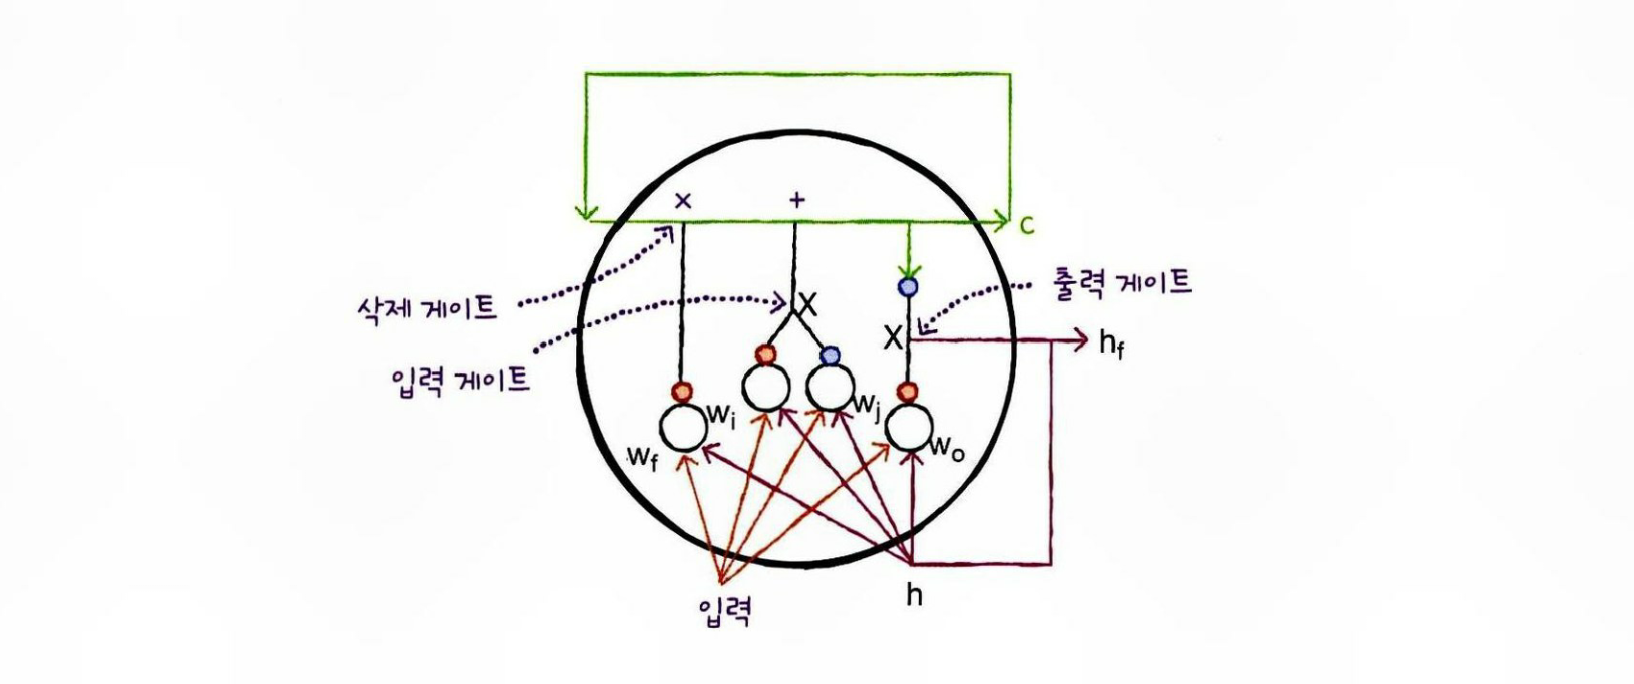


---

##### **LSTM 신경망 훈련하기**

In [33]:
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

# IMDB 리뷰 데이터를 로드하고 훈련 세트와 검증 세트로 구분
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

In [34]:
# 각 샘플의 길이를 100에 맞추고 부족할 때는 패딩을 추가
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [35]:
# LSTM 셀을 사용한 순환층 생성
import keras

model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))
model_lstm.add(keras.layers.Embedding(500, 16))
model_lstm.add(keras.layers.LSTM(8))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))

In [36]:
# 모델 구조 출력
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) 
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras', 
                                                save_best_only=True) 
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, 
                                                  restore_best_weights=True) 
history = model_lstm.fit(train_seq, train_target, epochs=100, batch_size=64, 
                         validation_data=(val_seq, val_target), 
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.6165 - loss: 0.6452 - val_accuracy: 0.7516 - val_loss: 0.5159
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.7840 - loss: 0.4726 - val_accuracy: 0.7840 - val_loss: 0.4522
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7965 - loss: 0.4419 - val_accuracy: 0.8026 - val_loss: 0.4323
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8043 - loss: 0.4230 - val_accuracy: 0.8034 - val_loss: 0.4268
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8155 - loss: 0.4038 - val_accuracy: 0.8034 - val_loss: 0.4214
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8161 - loss: 0.4010 - val_accuracy: 0.7790 - val_loss: 0.4688
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8175 - loss: 0.3971 - val_accuracy: 0.8054 - val_loss: 0.4216
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8238 - loss: 0

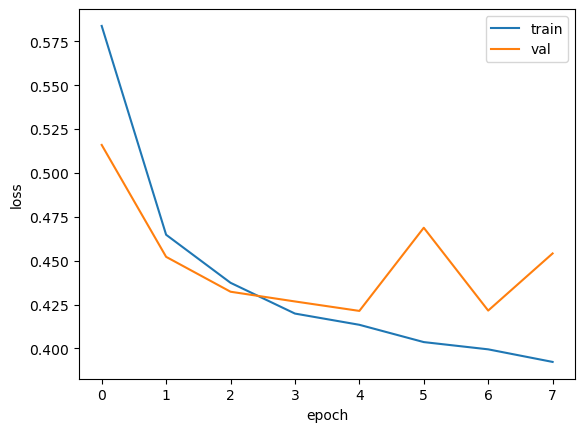

In [38]:
# 훈련 손실과 검증 손실을 그래프로 확인
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val') 
plt.xlabel('epoch') 
plt.ylabel('loss') 
plt.legend() 
plt.show()

훈련 손실은 잘 줄어들지만, 과대적합은 억제하지 못한 것으로 추정

---

##### **순환층에 드롭아웃 적용하기**

순환층은 자체적으로 드롭아웃 기능을 제공, SimpleRNN과 LSTM 클래스 모두 dropout 매개변수와 recurrent_dropout 매개변수를 가지고 있음

dropout 매개변수는 셀의 입력에 드롭아웃을 적용하고 recurrent_dropout은 순환되는 은닉 상태에 드롭아웃을 적용

하지만 기술적인 문제로 인해 recurrent_dropout을 사용하면 GPU를 사용하여 모델을 훈련하지 못하기 때문에 모델의 속도가 크게 느려짐


In [39]:
# LSTM 클래스에 드롭아웃을 적용
model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Input(shape=(100,)))
model_dropout.add(keras.layers.Embedding(500, 16))
model_dropout.add(keras.layers.LSTM(8, dropout=0.2))
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

In [40]:
# 모델을 (이전과 동일한 조건으로) 훈련
model_dropout.compile(optimizer='adam', loss='binary_crossentropy',
                      metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.keras',
                                                save_best_only=True)
ealry_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64,
                            validation_data=(val_seq, val_target),
                            callbacks=[checkpoint_cb, ealry_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.5708 - loss: 0.6665 - val_accuracy: 0.7676 - val_loss: 0.5004
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7776 - loss: 0.4811 - val_accuracy: 0.7894 - val_loss: 0.4557
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7862 - loss: 0.4561 - val_accuracy: 0.7888 - val_loss: 0.4565
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8081 - loss: 0.4259 - val_accuracy: 0.7982 - val_loss: 0.4323
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8076 - loss: 0.4199 - val_accuracy: 0.8038 - val_loss: 0.4277
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8132 - loss: 0.4156 - val_accuracy: 0.7982 - val_loss: 0.4293
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8064 - loss: 0.4160 - val_accuracy: 0.8048 - val_loss: 0.4362
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8174 - loss: 0

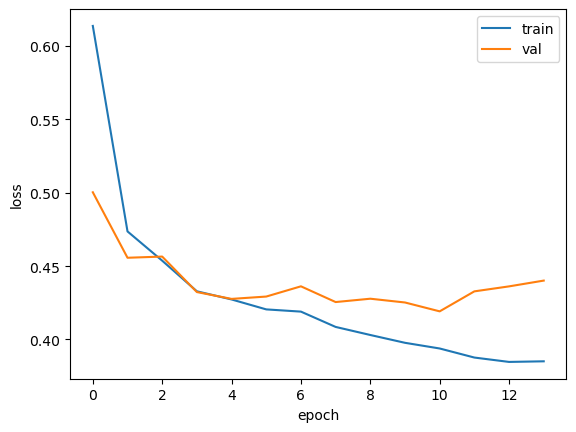

In [41]:
# 훈련 손실과 검증 손실을 그래프로 확인
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val') 
plt.xlabel('epoch') 
plt.ylabel('loss') 
plt.legend() 
plt.show()

---

##### **2개의 층을 연결하기**

순환층은 기본적으로 샘플의 마지막 타임스텝에 대한 은닉 상태만 다음 층(일반적으로 밀집층)으로 출력

이는 시퀀스 전체 정보를 압축하여 최종 결과를 도출할 때 사용

순환층을 여러 개 쌓을 경우, 다음 순환층은 전체 순차 데이터(모든 타임스텝의 정보)를 입력으로 받아야 함

따라서 첫 번째 층부터 마지막 층 바로 앞까지의 모든 중간 순환층들은 모든 타임스텝에 대한 은닉 상태를 출력

이를 통해 시퀀스 형태의 데이터가 끊어지지 않고 다음 순환층으로 전달


In [42]:
# 케라스의 순환층에서 모든 타입스텝의 은닉 상태를 출력

model_2lstm = keras.Sequential()
model_2lstm.add(keras.layers.Input(shape=(100,)))
model_2lstm.add(keras.layers.Embedding(500, 16))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2))
model_2lstm.add(keras.layers.Dense(1, activation='sigmoid'))
model_2lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# 모델을 (이전과 동일한 조건으로) 훈련
model_2lstm.compile(optimizer='adam', loss='binary_crossentropy',
                      metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2lstm-model.keras',
                                                save_best_only=True)
ealry_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_2lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
                          validation_data=(val_seq, val_target),
                          callbacks=[checkpoint_cb, ealry_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.5827 - loss: 0.6581 - val_accuracy: 0.7354 - val_loss: 0.5307
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.7659 - loss: 0.5030 - val_accuracy: 0.7898 - val_loss: 0.4465
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.7970 - loss: 0.4457 - val_accuracy: 0.7862 - val_loss: 0.4451
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.8034 - loss: 0.4223 - val_accuracy: 0.7994 - val_loss: 0.4296
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.8053 - loss: 0.4251 - val_accuracy: 0.7930 - val_loss: 0.4302
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8044 - loss: 0.4202 - val_accuracy: 0.8048 - val_loss: 0.4240
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8089 - loss: 0.4122 - val_accuracy: 0.8070 - val_loss: 0.4244
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.8202 - loss: 0

일반적으로 순환층을 쌓으면 성능이 높아짐

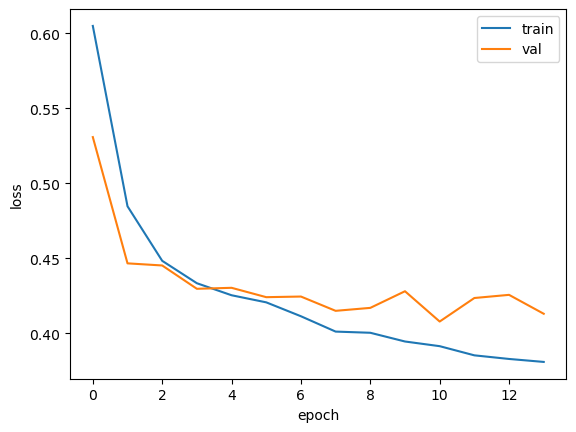

In [44]:
# 손실 그래프를 그려 훈련 과정 확인
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val') 
plt.xlabel('epoch') 
plt.ylabel('loss') 
plt.legend() 
plt.show()

---

##### **GRU 구조**

LSTM의 복잡성을 줄여 계산 효율성을 높이고도 유사한 성능을 내도록 고안된 순환 신경망 셀 구조

1\) 정의 및 특징
- Gated Recurrent Unit
- LSTM을 간소화한 버전으로 간주됨
- LSTM과 달리 셀 상태($c$)를 계산하지 않고, 은닉 상태($h$) 하나만 포함
2\) 내부 구조 및 작동 방식

|소형 셀|활성화 함수|역할|
|-----|-----|---|
|$W_z$ 셀|시그모이드($\sigma$)|업데이트 게이트: 삭제 및 입력 기능을 통합적으로 수행|
|$W_r$ 셀|시그모이드($\sigma$)|리셋 게이트: 이전 은닉 상태 중 얼마나 무시(삭제)할지 결정하여 $W_g$ 셀의 은닉 상태 입력에 적용
|$W_g$ 셀|$\tanh$|후보 은닉 상태($\tilde{h}_t$)를 생성하며, 새로운 정보를 저장할 준비를 함|

- 삭제 기능($W_z$의 출력): $W_z$ 셀의 출력이 이전 은닉 상태에 바로 곱해져 삭제역할을 수행
- 입력 기능($W_z$의 반전): $W_z$ 셀의 출력을 1에서 뺀 값($1 - W_z$)이 $W_g$ 셀의 출력에 곱해져 새로운 정보의 입력을 제어
    - 즉, 삭제할 정보가 많을수록 (삭제 게이트 $\approx 1$), 새로운 정보를 받아들이는 양은 줄어듬 ($1-W_z \approx 0$)

3\) 효율성

GRU는 LSTM에 비해 가중치 개수가 적기 때문에 계산량이 적음

그럼에도 불구하고 LSTM 못지않은 좋은 성능을 내는 것으로 알려져 있어, 효율성이 중요한 시나리오에서 선호되는 경향이 있음

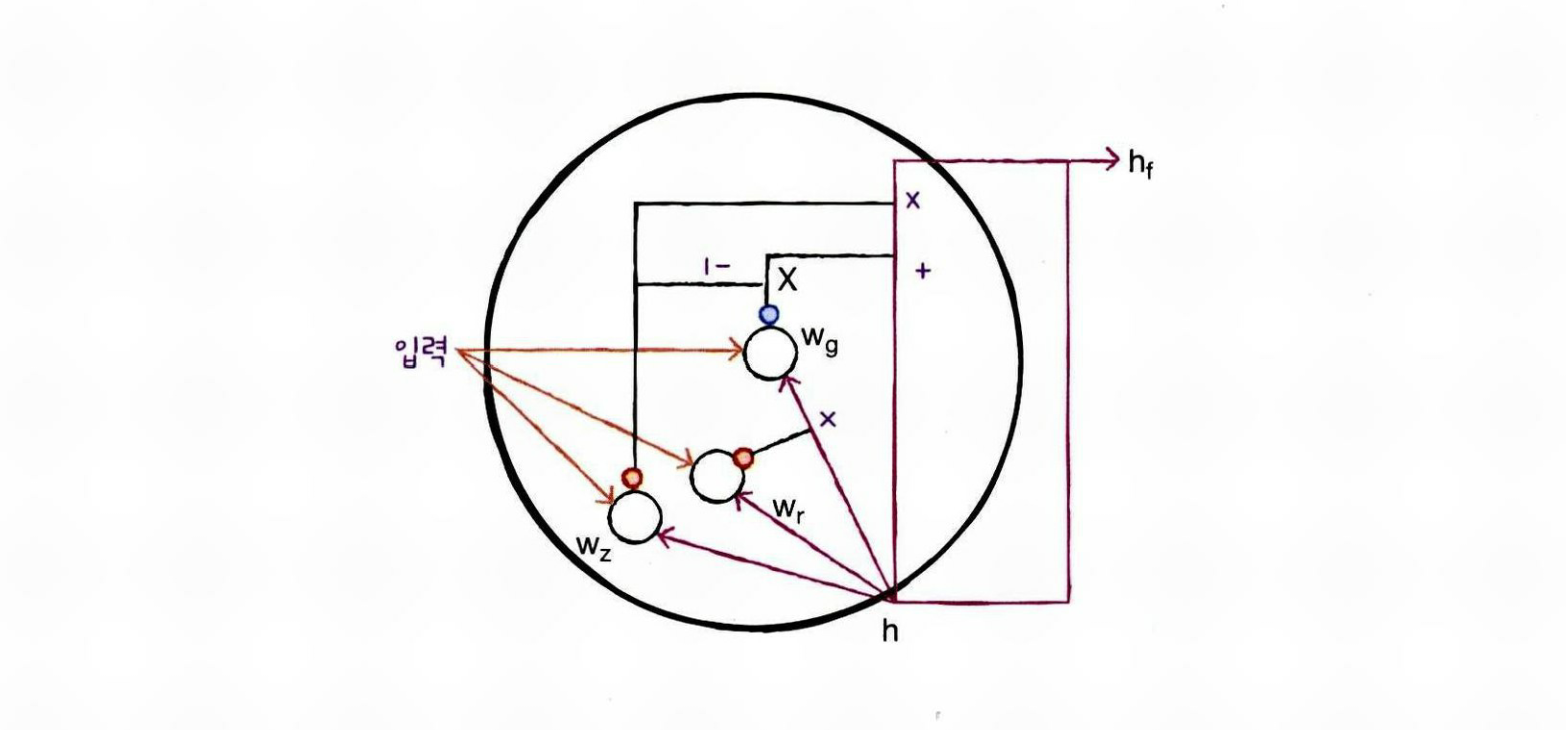

---

##### **GRU 신경망 훈련하기**

In [45]:
model_gru = keras.Sequential()
model_gru.add(keras.layers.Input(shape=(100,)))
model_gru.add(keras.layers.Embedding(500, 16))
model_gru.add(keras.layers.GRU(8, dropout=0.2))
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))

In [46]:
# 모델 구조 확인
model_gru.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model_gru.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.keras',
                                                save_best_only=True)
ealry_stopping_cb = keras.callbacks.EarlyStopping(patience=3, 
                                                  restore_best_weights=True)
history = model_gru.fit(train_seq, train_target, epochs=100, batch_size=64,
                        validation_data=(val_seq, val_target),
                        callbacks=[checkpoint_cb, ealry_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.5673 - loss: 0.6706 - val_accuracy: 0.7562 - val_loss: 0.5015
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7664 - loss: 0.4918 - val_accuracy: 0.7700 - val_loss: 0.4842
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7873 - loss: 0.4588 - val_accuracy: 0.7828 - val_loss: 0.4642
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8012 - loss: 0.4376 - val_accuracy: 0.7944 - val_loss: 0.4428
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8040 - loss: 0.4320 - val_accuracy: 0.8012 - val_loss: 0.4332
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8054 - loss: 0.4281 - val_accuracy: 0.8020 - val_loss: 0.4364
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8083 - loss: 0.4287 - val_accuracy: 0.7924 - val_loss: 0.4484
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.8106 - loss: 0

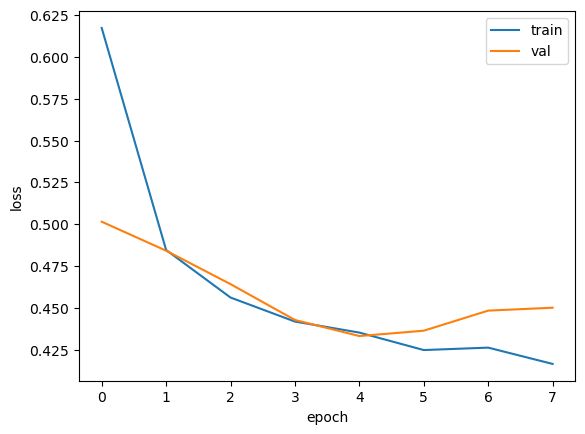

In [48]:
# 모델 손실을 그래프로 확인
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

LSTM 모델과 거의 동일한 성능을 보이는 것을 확인할 수 있음